# Automated Pneumonia Detection in Chest X-Rays for Emergency Triage Support

**AI in Medicine and Healthcare — Project**  
Insper Institute of Education and Research | 10th Semester — Computer Engineering | 2026  
**Team:** João Pedro Rodrigues dos Santos & Pedro Toledo Piza Civita

---

**Dataset:** RSNA Pneumonia Detection Challenge (2018) — ~30,000 frontal-view chest radiographs  
**Primary Metric:** Sensitivity ≥ 95% @ Specificity = 95%  
**Architecture:** DenseNet-121 (CheXNet baseline) + EfficientNet-B4 (comparison)

> **Clinical Goal:** Reduce time-to-report for critical pneumonia cases from >24h to <2h in Brazilian emergency units by flagging suspicious X-rays in the radiologist's PACS worklist.

## 0. Setup & Configuration

In [18]:
# ============================================================
# 0.1  Installs (run once — restart runtime after if needed)
# ============================================================
!pip install pydicom kaggle albumentations grad-cam timm -q

In [19]:
# ============================================================
# 0.2  Imports
# ============================================================
import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    confusion_matrix, classification_report, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pydicom

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import timm
from torch.cuda.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ============================================================
# 0.3  Reproducibility
# ============================================================
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")

Device: cuda
GPU:    Tesla T4


In [20]:
# ============================================================
# 0.4  Download dataset from Kaggle
# ============================================================
# OPTION A: Google Colab — upload your kaggle.json via Colab UI
#   1. Go to kaggle.com → Settings → API → Create New Token (downloads kaggle.json)
#   2. Run this cell — it will prompt you to upload the file
#
# OPTION B: Local / GPU cluster — place kaggle.json at ~/.kaggle/kaggle.json
#   mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

import os
from pathlib import Path

DATA_DIR = Path("./rsna-pneumonia-detection-challenge")

if not DATA_DIR.exists():
    # --- Setup Kaggle credentials ---
    kaggle_json = Path.home() / ".kaggle" / "kaggle.json"

    if not kaggle_json.exists():
        try:
            # Google Colab: upload via browser
            from google.colab import files
            print("Upload your kaggle.json (from kaggle.com → Settings → API → Create New Token):")
            uploaded = files.upload()
            kaggle_json.parent.mkdir(parents=True, exist_ok=True)
            kaggle_json.write_bytes(list(uploaded.values())[0])
            kaggle_json.chmod(0o600)
            print("kaggle.json saved!")
        except ImportError:
            # Not on Colab — check environment variables
            if "KAGGLE_USERNAME" not in os.environ:
                raise RuntimeError(
                    "Kaggle credentials not found!\n"
                    "Either:\n"
                    "  1. Place kaggle.json at ~/.kaggle/kaggle.json\n"
                    "  2. Set KAGGLE_USERNAME and KAGGLE_KEY environment variables\n"
                    "Download kaggle.json from: kaggle.com → Settings → API → Create New Token"
                )

    # --- Accept competition rules (required once) ---
    # You must also accept the rules at:
    # https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/rules
    print("NOTE: You must accept the competition rules at:")
    print("  https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/rules")
    print()

    # --- Download ---
    print("Downloading RSNA Pneumonia Detection dataset (~3.4 GB)...")
    !kaggle competitions download -c rsna-pneumonia-detection-challenge -p .

    # --- Extract ---
    print("\nExtracting...")
    !mkdir -p {DATA_DIR}
    !unzip -q -o rsna-pneumonia-detection-challenge.zip -d {DATA_DIR}
    !rm -f rsna-pneumonia-detection-challenge.zip
    print("Done!")
else:
    print(f"Dataset already exists at {DATA_DIR}")

# --- List contents ---
print(f"\nDataset contents:")
for p in sorted(DATA_DIR.iterdir()):
    if p.is_dir():
        n_files = len(list(p.iterdir()))
        print(f"  {p.name}/  ({n_files:,} files)")
    else:
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.name}  ({size_mb:.1f} MB)")

Dataset already exists at rsna-pneumonia-detection-challenge

Dataset contents:
  GCP Credits Request Link - RSNA.txt  (0.0 MB)
  stage_2_detailed_class_info.csv  (1.6 MB)
  stage_2_sample_submission.csv  (0.2 MB)
  stage_2_test_images/  (3,000 files)
  stage_2_train_images/  (26,684 files)
  stage_2_train_labels.csv  (1.5 MB)


In [21]:
# ============================================================
# 0.5  Paths configuration
# ============================================================
# The download cell above places files in ./rsna-pneumonia-detection-challenge/
# Adjust DATA_DIR if you placed the data elsewhere.

DATA_DIR       = Path("./rsna-pneumonia-detection-challenge")
TRAIN_IMG_DIR  = DATA_DIR / "stage_2_train_images"
TEST_IMG_DIR   = DATA_DIR / "stage_2_test_images"
LABELS_CSV     = DATA_DIR / "stage_2_train_labels.csv"
DETAIL_CSV     = DATA_DIR / "stage_2_detailed_class_info.csv"
OUTPUT_DIR     = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Verify paths exist
print("Checking paths:")
all_ok = True
for p in [LABELS_CSV, DETAIL_CSV, TRAIN_IMG_DIR]:
    status = "OK" if p.exists() else "NOT FOUND"
    if not p.exists(): all_ok = False
    print(f"  {status} — {p}")

if all_ok:
    n_train = len(list(TRAIN_IMG_DIR.glob('*.dcm')))
    print(f"\nAll good! {n_train:,} DICOM files in training set.")
else:
    print("\nSome paths are missing — check the download step above.")

Checking paths:
  OK — rsna-pneumonia-detection-challenge/stage_2_train_labels.csv
  OK — rsna-pneumonia-detection-challenge/stage_2_detailed_class_info.csv
  OK — rsna-pneumonia-detection-challenge/stage_2_train_images

All good! 26,684 DICOM files in training set.


---
## 1. Data Loading & Exploratory Analysis (Weeks 1–2)

The RSNA dataset has **3 classes** at the image level:
- **Lung Opacity** (pneumonia) — with bounding box annotations
- **No Lung Opacity / Not Normal** — abnormal but not pneumonia
- **Normal** — healthy chest X-ray

For our **binary triage task**, we merge the last two into a single "No Pneumonia" class.

In [22]:
import pandas as pd


# ============================================================
# 1.1  Load CSV labels
# ============================================================
labels_df = pd.read_csv(LABELS_CSV)
detail_df = pd.read_csv(DETAIL_CSV)

print(f"Labels shape:  {labels_df.shape}")
print(f"Detail shape:  {detail_df.shape}")
print()
print("--- Labels sample ---")
display(labels_df.head(10))
print()
print("--- Detailed class info sample ---")
display(detail_df.head(10))

Labels shape:  (30227, 6)
Detail shape:  (30227, 2)

--- Labels sample ---


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1



--- Detailed class info sample ---


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity
5,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity
6,00569f44-917d-4c86-a842-81832af98c30,No Lung Opacity / Not Normal
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,No Lung Opacity / Not Normal
8,00704310-78a8-4b38-8475-49f4573b2dbb,Lung Opacity
9,00704310-78a8-4b38-8475-49f4573b2dbb,Lung Opacity


In [23]:
# ============================================================
# 1.2  Understand the label structure
# ============================================================
# The labels CSV has one row per BOUNDING BOX (patients with pneumonia
# can have multiple rows). The 'Target' column: 1 = opacity present.
# The detail CSV has the 3-class info.

print("Target distribution (row-level, includes duplicate patientIds):")
print(labels_df["Target"].value_counts())
print()

# Merge to get the 3-class label per image
detail_unique = detail_df.drop_duplicates(subset="patientId")
print("3-class distribution (unique patients):")
print(detail_unique["class"].value_counts())

Target distribution (row-level, includes duplicate patientIds):
Target
0    20672
1     9555
Name: count, dtype: int64

3-class distribution (unique patients):
class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64


In [24]:
# ============================================================
# 1.3  Build a clean per-patient dataframe
# ============================================================
# For CLASSIFICATION, we need one row per patient with:
#   - binary target (1 = pneumonia, 0 = no pneumonia)
#   - bounding boxes (list) for patients with pneumonia

# Step 1: get unique patient-level binary labels
patient_labels = labels_df.groupby("patientId").agg(
    target=("Target", "max")  # 1 if ANY box exists
).reset_index()

# Step 2: merge 3-class info
patient_labels = patient_labels.merge(
    detail_unique[["patientId", "class"]],
    on="patientId",
    how="left"
)

# Step 3: collect bounding boxes for positive cases
bbox_df = labels_df[labels_df["Target"] == 1][["patientId", "x", "y", "width", "height"]]
bboxes_grouped = bbox_df.groupby("patientId").apply(
    lambda g: g[["x", "y", "width", "height"]].values.tolist()
).reset_index(name="bboxes")

patient_labels = patient_labels.merge(bboxes_grouped, on="patientId", how="left")
patient_labels["bboxes"] = patient_labels["bboxes"].apply(
    lambda x: x if isinstance(x, list) else []
)
patient_labels["num_boxes"] = patient_labels["bboxes"].apply(len)

print(f"Total unique patients: {len(patient_labels)}")
print(f"Pneumonia (target=1):  {patient_labels['target'].sum()}")
print(f"No Pneumonia (target=0): {(patient_labels['target'] == 0).sum()}")
print(f"\nClass breakdown:")
print(patient_labels["class"].value_counts())
print()
display(patient_labels.head())

Total unique patients: 26684
Pneumonia (target=1):  6012
No Pneumonia (target=0): 20672

Class breakdown:
class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64



,patientId,target,class,bboxes,num_boxes
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,[],0
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,[],0
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,"[[316.0, 318.0, 170.0, 478.0], [660.0, 375.0, ...",2
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,"[[570.0, 282.0, 269.0, 409.0], [83.0, 227.0, 2...",2
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Lung Opacity,"[[66.0, 160.0, 373.0, 608.0], [552.0, 164.0, 3...",2


In [25]:
# ============================================================
# 1.4  DICOM metadata extraction (sample)
# ============================================================
def read_dicom_metadata(patient_id, img_dir=TRAIN_IMG_DIR):
    """Read a DICOM file and extract key metadata."""
    dcm_path = img_dir / f"{patient_id}.dcm"
    dcm = pydicom.dcmread(str(dcm_path))
    return {
        "patientId": patient_id,
        "age": int(dcm.PatientAge) if hasattr(dcm, "PatientAge") else None,
        "sex": str(dcm.PatientSex) if hasattr(dcm, "PatientSex") else None,
        "view": str(dcm.ViewPosition) if hasattr(dcm, "ViewPosition") else None,
        "rows": dcm.Rows,
        "cols": dcm.Columns,
        "bits_stored": dcm.BitsStored,
    }

# Extract metadata for all patients (may take a few minutes)
print("Extracting DICOM metadata...")
meta_records = []
for pid in patient_labels["patientId"].values:
    try:
        meta_records.append(read_dicom_metadata(pid))
    except Exception as e:
        print(f"Error reading metadata for patientId {pid}: {e}") # Print the error
        # pass  # skip if file missing

meta_df = pd.DataFrame(meta_records)
df = patient_labels.merge(meta_df, on="patientId", how="left")

print(f"Metadata extracted for {len(meta_df)} / {len(patient_labels)} patients")
display(df.head())

Extracting DICOM metadata...
Metadata extracted for 26684 / 26684 patients


,patientId,target,class,bboxes,num_boxes,age,sex,view,rows,cols,bits_stored
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,[],0,51,F,PA,1024,1024,8
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,[],0,19,F,AP,1024,1024,8
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,"[[316.0, 318.0, 170.0, 478.0], [660.0, 375.0, ...",2,25,F,AP,1024,1024,8
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,"[[570.0, 282.0, 269.0, 409.0], [83.0, 227.0, 2...",2,40,M,AP,1024,1024,8
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Lung Opacity,"[[66.0, 160.0, 373.0, 608.0], [552.0, 164.0, 3...",2,57,M,PA,1024,1024,8


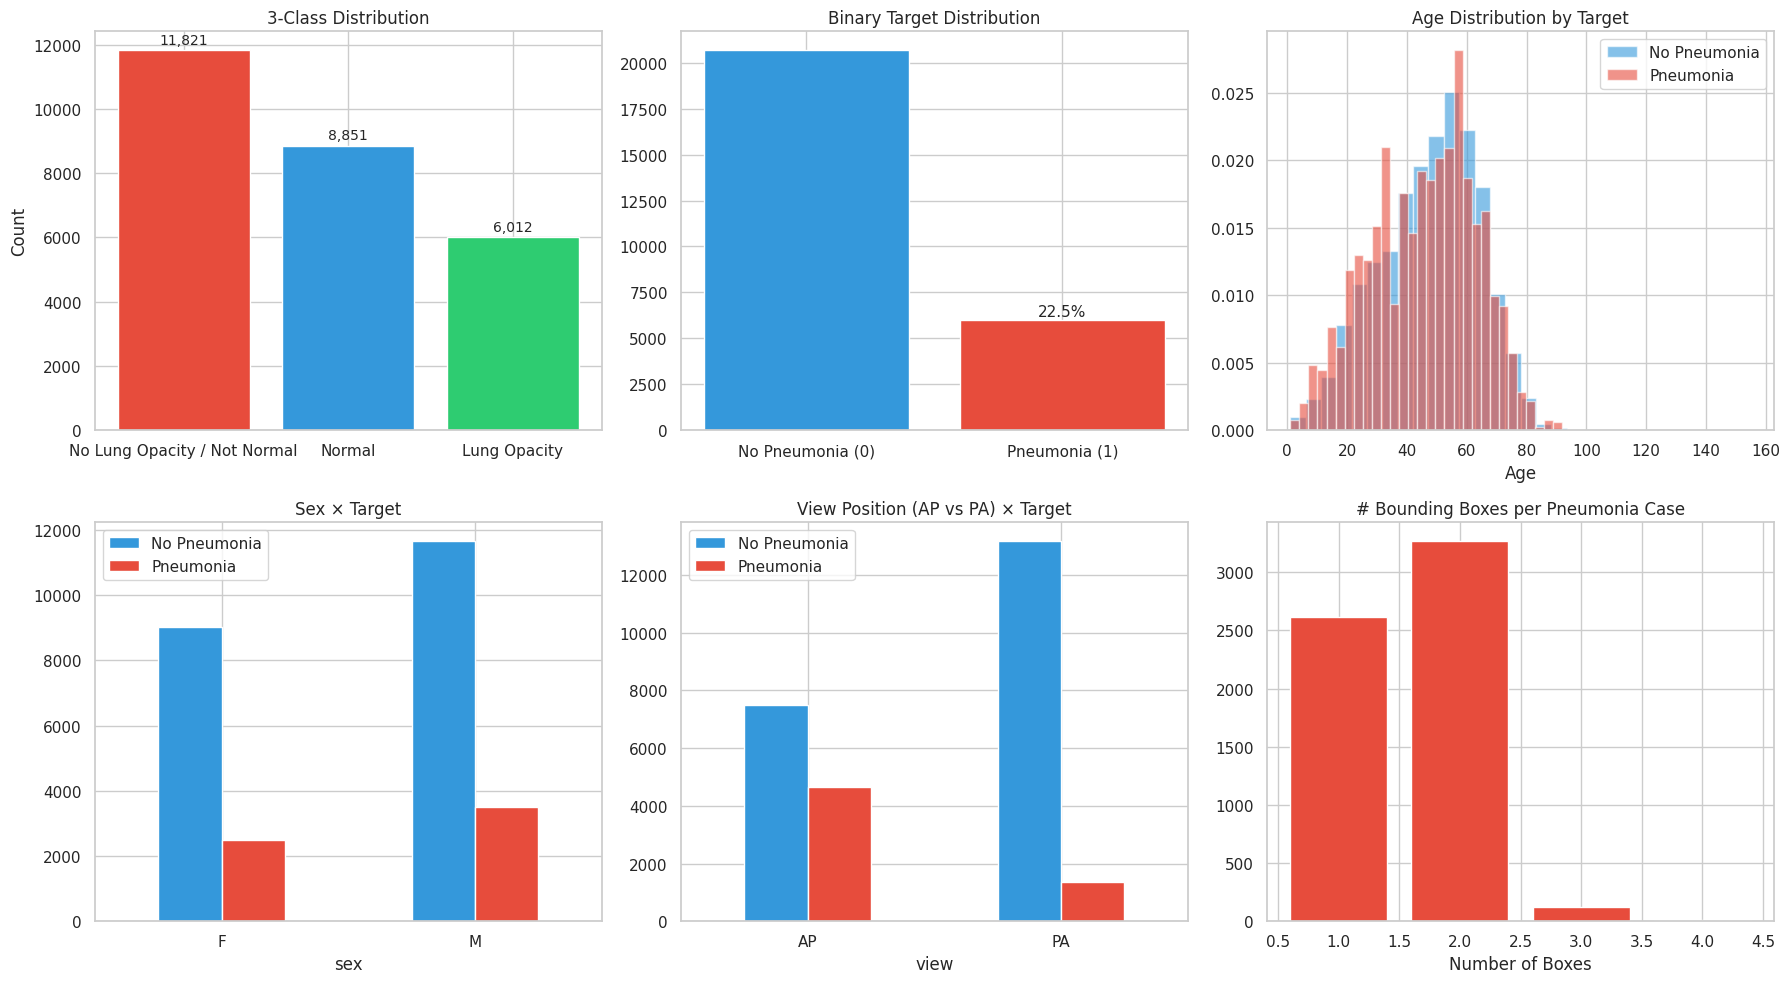

Saved: outputs/eda_overview.png


In [26]:
# ============================================================
# 1.5  EDA Visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (a) 3-class distribution
class_counts = df["class"].value_counts()
axes[0, 0].bar(class_counts.index, class_counts.values,
               color=["#e74c3c", "#3498db", "#2ecc71"])
axes[0, 0].set_title("3-Class Distribution")
axes[0, 0].set_ylabel("Count")
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0, 0].text(i, cnt + 200, f"{cnt:,}", ha="center", fontsize=10)

# (b) Binary target distribution
target_counts = df["target"].value_counts()
axes[0, 1].bar(["No Pneumonia (0)", "Pneumonia (1)"], target_counts.values,
               color=["#3498db", "#e74c3c"])
axes[0, 1].set_title("Binary Target Distribution")
pct = target_counts[1] / len(df) * 100
axes[0, 1].text(1, target_counts[1] + 200, f"{pct:.1f}%", ha="center", fontsize=11)

# (c) Age distribution by target
for t, color, label in [(0, "#3498db", "No Pneumonia"), (1, "#e74c3c", "Pneumonia")]:
    subset = df[df["target"] == t]["age"].dropna()
    axes[0, 2].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
axes[0, 2].set_title("Age Distribution by Target")
axes[0, 2].set_xlabel("Age")
axes[0, 2].legend()

# (d) Sex distribution
sex_target = df.groupby(["sex", "target"]).size().unstack(fill_value=0)
sex_target.plot(kind="bar", ax=axes[1, 0], color=["#3498db", "#e74c3c"])
axes[1, 0].set_title("Sex × Target")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(["No Pneumonia", "Pneumonia"])

# (e) View position distribution
view_target = df.groupby(["view", "target"]).size().unstack(fill_value=0)
view_target.plot(kind="bar", ax=axes[1, 1], color=["#3498db", "#e74c3c"])
axes[1, 1].set_title("View Position (AP vs PA) × Target")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(["No Pneumonia", "Pneumonia"])

# (f) Number of bounding boxes per positive case
pos_df = df[df["target"] == 1]
box_counts = pos_df["num_boxes"].value_counts().sort_index()
axes[1, 2].bar(box_counts.index, box_counts.values, color="#e74c3c")
axes[1, 2].set_title("# Bounding Boxes per Pneumonia Case")
axes[1, 2].set_xlabel("Number of Boxes")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/eda_overview.png")

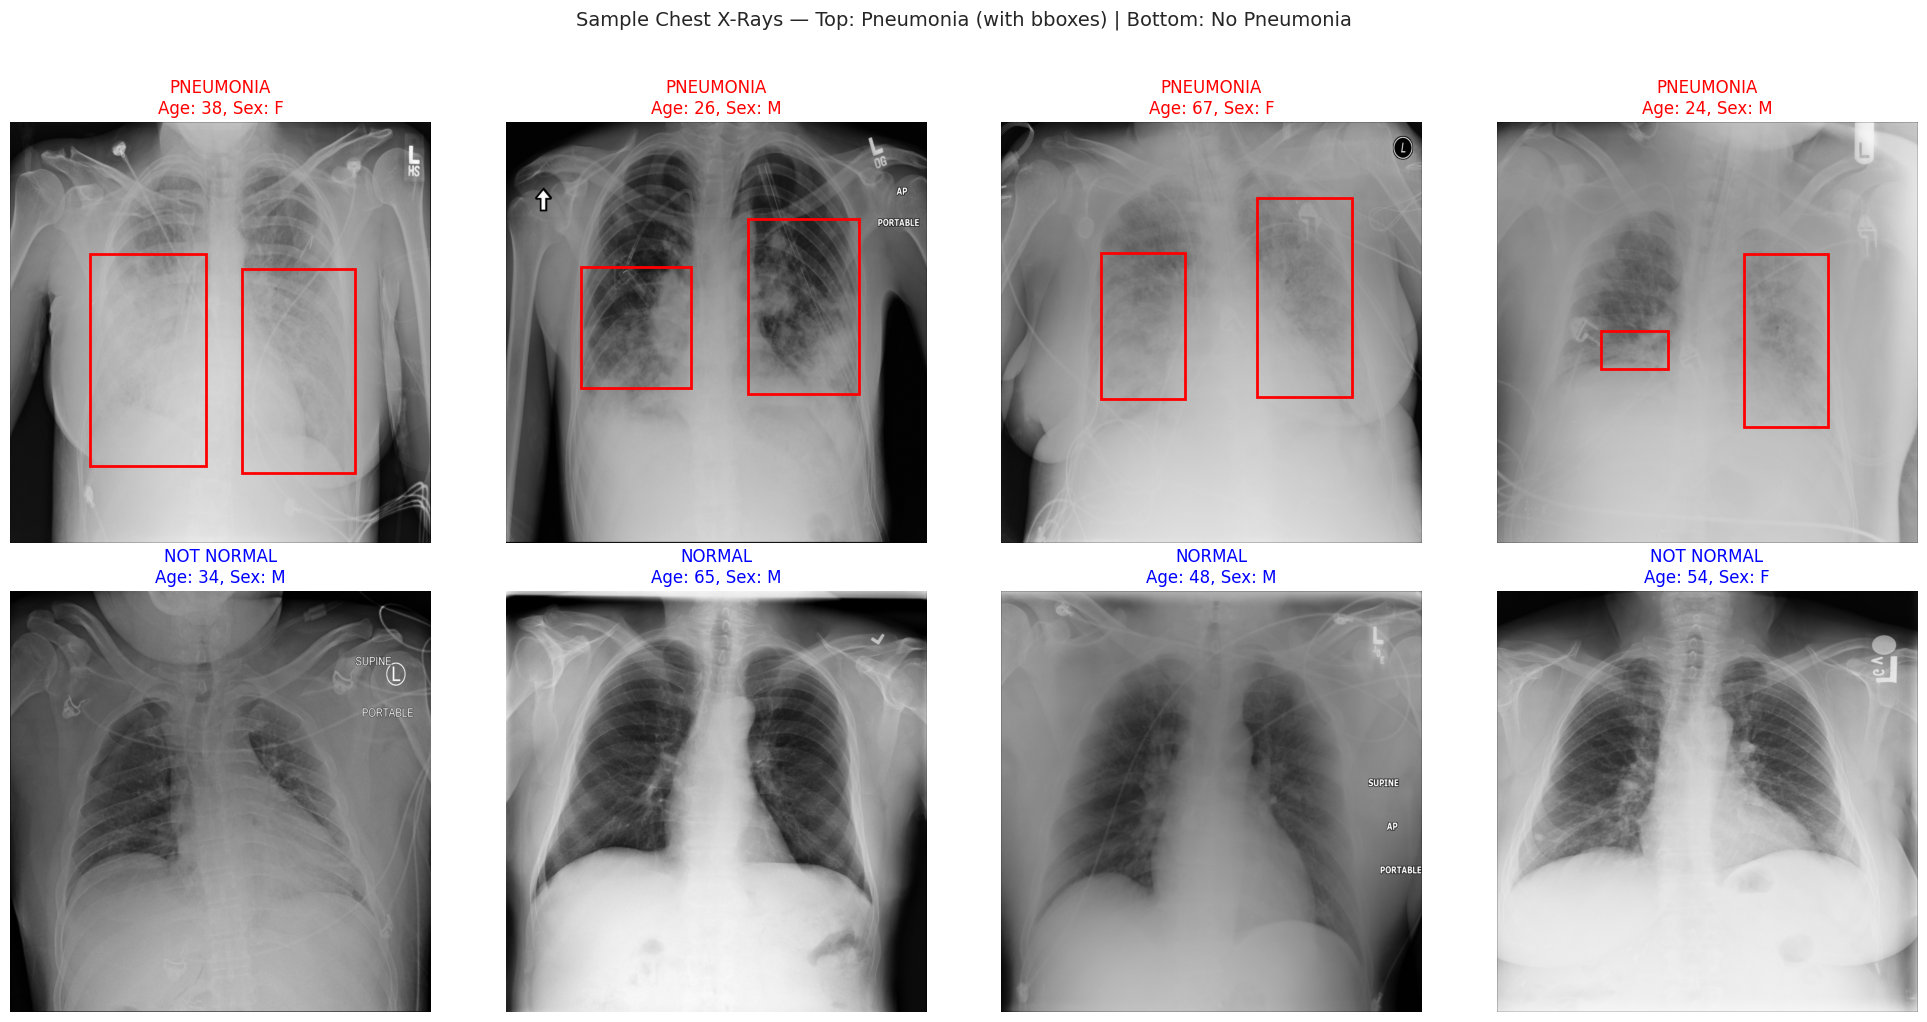

In [27]:
# ============================================================
# 1.6  Visualize sample X-rays with bounding boxes
# ============================================================
def load_dicom_image(patient_id, img_dir=TRAIN_IMG_DIR):
    """Load DICOM pixel array, normalized to [0, 255]."""
    dcm = pydicom.dcmread(str(img_dir / f"{patient_id}.dcm"))
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return img.astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Pneumonia cases with bounding boxes
pneumonia_samples = df[df["target"] == 1].sample(4, random_state=SEED)
for i, (_, row) in enumerate(pneumonia_samples.iterrows()):
    img = load_dicom_image(row["patientId"])
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"PNEUMONIA\nAge: {row['age']}, Sex: {row['sex']}", color="red")
    axes[0, i].axis("off")
    for bbox in row["bboxes"]:
        x, y, w, h = bbox
        rect = patches.Rectangle((x, y), w, h,
                                  linewidth=2, edgecolor="red", facecolor="none")
        axes[0, i].add_patch(rect)

# Row 2: Normal / No Opacity cases
normal_samples = df[df["target"] == 0].sample(4, random_state=SEED)
for i, (_, row) in enumerate(normal_samples.iterrows()):
    img = load_dicom_image(row["patientId"])
    axes[1, i].imshow(img, cmap="gray")
    lbl = row["class"].replace("No Lung Opacity / Not Normal", "Not Normal")
    axes[1, i].set_title(f"{lbl.upper()}\nAge: {row['age']}, Sex: {row['sex']}", color="blue")
    axes[1, i].axis("off")

plt.suptitle("Sample Chest X-Rays — Top: Pneumonia (with bboxes) | Bottom: No Pneumonia",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_xrays.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Data Pipeline & Splitting

**Strategy (from proposal):**
- Re-split training data into **80% train / 10% val / 10% test** using stratified sampling
- Stratify on the binary target to ensure balanced class representation
- All splits are patient-level (no data leakage)

In [28]:
# ============================================================
# 2.1  Stratified train/val/test split
# ============================================================
# 80% train, 10% val, 10% test — stratified by binary target
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["target"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["target"], random_state=SEED
)

print(f"Train: {len(train_df)} ({train_df['target'].mean():.3f} positive rate)")
print(f"Val:   {len(val_df)} ({val_df['target'].mean():.3f} positive rate)")
print(f"Test:  {len(test_df)} ({test_df['target'].mean():.3f} positive rate)")

Train: 21347 (0.225 positive rate)
Val:   2668 (0.225 positive rate)
Test:  2669 (0.225 positive rate)


In [29]:
# ============================================================
# 2.2  Compute class weights for Weighted BCE Loss
# ============================================================
n_pos = train_df["target"].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f"Positive weight (neg/pos ratio): {pos_weight.item():.2f}")
print(f"  → This compensates for class imbalance in BCE loss")

Positive weight (neg/pos ratio): 3.44
  → This compensates for class imbalance in BCE loss


In [30]:
# ============================================================
# 2.3  Image transforms (Albumentations)
# ============================================================
IMG_SIZE = 512  # DenseNet-121 can handle this; adjust for memory

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

In [31]:
# ============================================================
# 2.4  PyTorch Dataset
# ============================================================
class RSNAPneumoniaDataset(Dataset):
    """RSNA Pneumonia dataset — loads DICOM, returns 3-channel image + binary label."""

    def __init__(self, dataframe, img_dir, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = row["patientId"]
        target = row["target"]

        # Load DICOM
        dcm_path = self.img_dir / f"{patient_id}.dcm"
        dcm = pydicom.dcmread(str(dcm_path))
        img = dcm.pixel_array.astype(np.float32)

        # Normalize to [0, 255] and convert to 3-channel (for ImageNet pretrained models)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255.0
        img = img.astype(np.uint8)
        img = np.stack([img] * 3, axis=-1)  # H×W×3

        if self.transforms:
            augmented = self.transforms(image=img)
            img = augmented["image"]  # C×H×W tensor

        label = torch.tensor(target, dtype=torch.float32)
        return img, label

# Create datasets
train_ds = RSNAPneumoniaDataset(train_df, TRAIN_IMG_DIR, train_transforms)
val_ds   = RSNAPneumoniaDataset(val_df,   TRAIN_IMG_DIR, val_transforms)
test_ds  = RSNAPneumoniaDataset(test_df,  TRAIN_IMG_DIR, val_transforms)

print(f"Train dataset: {len(train_ds)} images")
print(f"Val dataset:   {len(val_ds)} images")
print(f"Test dataset:  {len(test_ds)} images")

Train dataset: 21347 images
Val dataset:   2668 images
Test dataset:  2669 images


In [32]:
# ============================================================
# 2.5  DataLoaders
# ============================================================
BATCH_SIZE = 16  # Adjust based on GPU memory (32 for A100, 8 for T4)
NUM_WORKERS = 4

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Sanity check
batch_imgs, batch_labels = next(iter(train_loader))
print(f"Batch images shape:  {batch_imgs.shape}")
print(f"Batch labels shape:  {batch_labels.shape}")
print(f"Label values:        {batch_labels[:8].tolist()}")

Batch images shape:  torch.Size([16, 3, 512, 512])
Batch labels shape:  torch.Size([16])
Label values:        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]


---
## 3. Baseline Model — Logistic Regression on Flattened Features

Before deep learning, we establish a simple baseline using logistic regression on
resized + flattened pixel features. This gives us a **floor** to beat.

In [33]:
# ============================================================
# 3.1  Extract flattened features (small resolution for speed)
# ============================================================
BASELINE_SIZE = 64  # 64×64 pixels → 4096 features per channel

def extract_flat_features(dataframe, img_dir, size=BASELINE_SIZE, max_samples=None):
    """Load images, resize to (size, size), flatten to 1D vector."""
    features, targets = [], []
    subset = dataframe if max_samples is None else dataframe.head(max_samples)

    for _, row in subset.iterrows():
        try:
            dcm = pydicom.dcmread(str(img_dir / f"{row['patientId']}.dcm"))
            img = dcm.pixel_array.astype(np.float32)
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            # Resize using simple array slicing (no dependency needed)
            from PIL import Image
            img_pil = Image.fromarray((img * 255).astype(np.uint8))
            img_resized = np.array(img_pil.resize((size, size))) / 255.0
            features.append(img_resized.flatten())
            targets.append(row["target"])
        except:
            continue

    return np.array(features), np.array(targets)

print("Extracting features for baseline...")
X_train_flat, y_train_flat = extract_flat_features(train_df, TRAIN_IMG_DIR)
X_val_flat, y_val_flat     = extract_flat_features(val_df, TRAIN_IMG_DIR)
X_test_flat, y_test_flat   = extract_flat_features(test_df, TRAIN_IMG_DIR)

print(f"Train features shape: {X_train_flat.shape}")
print(f"Val features shape:   {X_val_flat.shape}")
print(f"Test features shape:  {X_test_flat.shape}")

Extracting features for baseline...
Train features shape: (21347, 4096)
Val features shape:   (2668, 4096)
Test features shape:  (2669, 4096)


In [ ]:
# ============================================================
# 3.2  Train logistic regression baseline
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled   = scaler.transform(X_val_flat)
X_test_scaled  = scaler.transform(X_test_flat)

lr_model = LogisticRegression(
    max_iter=1000, C=1.0, solver="saga", random_state=SEED, n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train_flat)

# Predictions
y_val_proba  = lr_model.predict_proba(X_val_scaled)[:, 1]
y_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# AUC
val_auc  = roc_auc_score(y_val_flat, y_val_proba)
test_auc = roc_auc_score(y_test_flat, y_test_proba)
print(f"Logistic Regression Baseline:")
print(f"  Val  AUC-ROC: {val_auc:.4f}")
print(f"  Test AUC-ROC: {test_auc:.4f}")

In [ ]:
# ============================================================
# 3.3  Baseline: Sensitivity @ 95% Specificity
# ============================================================
def sensitivity_at_specificity(y_true, y_proba, target_spec=0.95):
    """Find sensitivity at a given specificity level."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    specificities = 1 - fpr
    # Find the threshold closest to target specificity
    idx = np.argmin(np.abs(specificities - target_spec))
    return tpr[idx], thresholds[idx], specificities[idx]

sens_val, thresh_val, spec_val = sensitivity_at_specificity(y_val_flat, y_val_proba)
sens_test, thresh_test, spec_test = sensitivity_at_specificity(y_test_flat, y_test_proba)

print(f"\nPrimary Metric — Sensitivity @ 95% Specificity:")
print(f"  Val:  Sens={sens_val:.4f}  (Spec={spec_val:.4f}, Thresh={thresh_val:.4f})")
print(f"  Test: Sens={sens_test:.4f} (Spec={spec_test:.4f}, Thresh={thresh_test:.4f})")
print(f"\n  → This is the floor. Deep learning should significantly improve this.")

---
## 4. Deep Learning Models (Weeks 3–4)

### 4.1 DenseNet-121 (Primary — CheXNet Baseline)

DenseNet-121 was chosen based on the **CheXNet** precedent (Rajpurkar et al., 2017).
Dense connections enable feature reuse, making it parameter-efficient (~8M params vs ~25M for ResNet-50).

**Training strategy — Progressive Unfreezing:**
1. **Phase 1:** Freeze backbone → train classifier head for 5 epochs
2. **Phase 2:** Unfreeze last 2 dense blocks → fine-tune with lr=1e-5 for 15–20 epochs

In [ ]:
# ============================================================
# 4.1  Model factory
# ============================================================
class PneumoniaClassifier(nn.Module):
    """Binary classifier wrapping a pretrained backbone."""

    def __init__(self, backbone="densenet121", pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone_name = backbone

        if backbone == "densenet121":
            self.model = models.densenet121(
                weights=models.DenseNet121_Weights.DEFAULT if pretrained else None
            )
            in_features = self.model.classifier.in_features
            self.model.classifier = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(in_features, 1)
            )
        elif backbone == "efficientnet_b4":
            self.model = timm.create_model(
                "efficientnet_b4", pretrained=pretrained, num_classes=1, drop_rate=dropout
            )
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

    def forward(self, x):
        return self.model(x).squeeze(-1)

    def freeze_backbone(self):
        """Freeze all layers except the classifier head."""
        if self.backbone_name == "densenet121":
            for param in self.model.features.parameters():
                param.requires_grad = False
        elif self.backbone_name == "efficientnet_b4":
            for name, param in self.model.named_parameters():
                if "classifier" not in name:
                    param.requires_grad = False

    def unfreeze_last_blocks(self, n_blocks=2):
        """Unfreeze the last n dense blocks (DenseNet) or stages (EfficientNet)."""
        if self.backbone_name == "densenet121":
            # DenseNet has: features.denseblock1, ..., denseblock4
            blocks_to_unfreeze = [f"denseblock{i}" for i in range(5 - n_blocks, 5)]
            for name, param in self.model.features.named_parameters():
                if any(block in name for block in blocks_to_unfreeze):
                    param.requires_grad = True
        elif self.backbone_name == "efficientnet_b4":
            # Unfreeze last n blocks
            all_blocks = [n for n, _ in self.model.named_parameters() if "blocks" in n]
            block_ids = sorted(set(n.split(".")[1] for n in all_blocks))
            unfreeze_ids = block_ids[-n_blocks:]
            for name, param in self.model.named_parameters():
                parts = name.split(".")
                if len(parts) > 1 and parts[1] in unfreeze_ids:
                    param.requires_grad = True

    def count_params(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

# Quick test
model = PneumoniaClassifier("densenet121", pretrained=True)
total, trainable = model.count_params()
print(f"DenseNet-121: {total/1e6:.1f}M total params, {trainable/1e6:.1f}M trainable")

model.freeze_backbone()
_, trainable_frozen = model.count_params()
print(f"  After freezing backbone: {trainable_frozen/1e6:.3f}M trainable")

model.unfreeze_last_blocks(2)
_, trainable_unfrozen = model.count_params()
print(f"  After unfreezing last 2 blocks: {trainable_unfrozen/1e6:.1f}M trainable")

In [ ]:
# ============================================================
# 4.2  Training engine
# ============================================================
class Trainer:
    """Training loop with mixed precision, early stopping, and metric tracking."""

    def __init__(self, model, criterion, optimizer, scheduler=None,
                 device=DEVICE, patience=5, output_dir=OUTPUT_DIR):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.patience = patience
        self.output_dir = Path(output_dir)
        self.scaler = GradScaler()

        self.history = {"train_loss": [], "val_loss": [], "val_auc": [],
                        "val_sens_at_spec95": [], "lr": []}
        self.best_auc = 0
        self.no_improve = 0

    def train_epoch(self, loader):
        self.model.train()
        losses = []
        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)

            self.optimizer.zero_grad()
            with autocast():
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            losses.append(loss.item())

        return np.mean(losses)

    @torch.no_grad()
    def validate(self, loader):
        self.model.eval()
        all_probs, all_labels, losses = [], [], []

        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)

            with autocast():
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            losses.append(loss.item())

        all_probs = np.array(all_probs)
        all_labels = np.array(all_labels)

        val_loss = np.mean(losses)
        auc = roc_auc_score(all_labels, all_probs)
        sens, _, _ = sensitivity_at_specificity(all_labels, all_probs, 0.95)

        return val_loss, auc, sens, all_probs, all_labels

    def fit(self, train_loader, val_loader, epochs=20, phase_name=""):
        print(f"\n{'='*60}")
        print(f"  Training: {phase_name} | {epochs} epochs | patience={self.patience}")
        print(f"{'='*60}")

        for epoch in range(1, epochs + 1):
            train_loss = self.train_epoch(train_loader)
            val_loss, val_auc, val_sens, _, _ = self.validate(val_loader)

            current_lr = self.optimizer.param_groups[0]["lr"]
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_auc"].append(val_auc)
            self.history["val_sens_at_spec95"].append(val_sens)
            self.history["lr"].append(current_lr)

            print(f"  Epoch {epoch:2d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val AUC: {val_auc:.4f} | "
                  f"Sens@Spec95: {val_sens:.4f} | "
                  f"LR: {current_lr:.2e}")

            # Early stopping on AUC
            if val_auc > self.best_auc:
                self.best_auc = val_auc
                self.no_improve = 0
                torch.save(self.model.state_dict(),
                           self.output_dir / "best_model.pt")
                print(f"    → New best AUC! Model saved.")
            else:
                self.no_improve += 1
                if self.no_improve >= self.patience:
                    print(f"    → Early stopping triggered (no improvement for {self.patience} epochs)")
                    break

            if self.scheduler:
                self.scheduler.step(val_auc)

        # Load best model
        self.model.load_state_dict(
            torch.load(self.output_dir / "best_model.pt", weights_only=True)
        )
        print(f"\n  Best validation AUC: {self.best_auc:.4f}")
        return self.history

    def plot_history(self, save_path=None):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(self.history["train_loss"], label="Train", linewidth=2)
        axes[0].plot(self.history["val_loss"], label="Val", linewidth=2)
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()

        axes[1].plot(self.history["val_auc"], label="Val AUC", linewidth=2, color="green")
        axes[1].axhline(y=0.5, color="gray", linestyle="--", label="Random")
        axes[1].set_title("Validation AUC-ROC")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylim(0.4, 1.0)
        axes[1].legend()

        axes[2].plot(self.history["val_sens_at_spec95"], label="Sens@Spec95",
                     linewidth=2, color="red")
        axes[2].set_title("Sensitivity @ 95% Specificity (Primary Metric)")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylim(0, 1.0)
        axes[2].legend()

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

In [ ]:
# ============================================================
# 4.3  Train DenseNet-121 — Phase 1 (Frozen Backbone)
# ============================================================
model_dn = PneumoniaClassifier("densenet121", pretrained=True, dropout=0.3)
model_dn.freeze_backbone()

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_phase1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_dn.parameters()),
    lr=1e-4, weight_decay=1e-5
)

trainer_dn = Trainer(
    model=model_dn,
    criterion=criterion,
    optimizer=optimizer_phase1,
    patience=5,
    output_dir=OUTPUT_DIR
)

history_p1 = trainer_dn.fit(
    train_loader, val_loader, epochs=5, phase_name="DenseNet-121 Phase 1 (Frozen)"
)

In [ ]:
# ============================================================
# 4.4  Train DenseNet-121 — Phase 2 (Unfreeze last 2 dense blocks)
# ============================================================
model_dn.unfreeze_last_blocks(n_blocks=2)
_, trainable = model_dn.count_params()
print(f"Trainable params after unfreezing: {trainable/1e6:.1f}M")

optimizer_phase2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_dn.parameters()),
    lr=1e-5, weight_decay=1e-5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_phase2, mode="max", factor=0.5, patience=3, verbose=True
)

trainer_dn.optimizer = optimizer_phase2
trainer_dn.scheduler = scheduler
trainer_dn.no_improve = 0  # Reset early stopping counter

history_p2 = trainer_dn.fit(
    train_loader, val_loader, epochs=20,
    phase_name="DenseNet-121 Phase 2 (Fine-tune)"
)

trainer_dn.plot_history(save_path=OUTPUT_DIR / "densenet121_training.png")

### 4.2 EfficientNet-B4 (Comparison Baseline)

EfficientNet uses compound scaling (depth, width, resolution) and typically achieves
better accuracy-per-FLOP than DenseNet. We train it with the same progressive unfreezing strategy.

In [ ]:
# ============================================================
# 4.5  Train EfficientNet-B4 (same protocol)
# ============================================================
model_eff = PneumoniaClassifier("efficientnet_b4", pretrained=True, dropout=0.3)
model_eff.freeze_backbone()

optimizer_eff_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_eff.parameters()),
    lr=1e-4, weight_decay=1e-5
)

trainer_eff = Trainer(
    model=model_eff,
    criterion=criterion,
    optimizer=optimizer_eff_p1,
    patience=5,
    output_dir=OUTPUT_DIR
)

# Phase 1
history_eff_p1 = trainer_eff.fit(
    train_loader, val_loader, epochs=5,
    phase_name="EfficientNet-B4 Phase 1 (Frozen)"
)

# Phase 2
model_eff.unfreeze_last_blocks(n_blocks=2)
optimizer_eff_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_eff.parameters()),
    lr=1e-5, weight_decay=1e-5
)
scheduler_eff = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff_p2, mode="max", factor=0.5, patience=3, verbose=True
)

trainer_eff.optimizer = optimizer_eff_p2
trainer_eff.scheduler = scheduler_eff
trainer_eff.no_improve = 0

history_eff_p2 = trainer_eff.fit(
    train_loader, val_loader, epochs=20,
    phase_name="EfficientNet-B4 Phase 2 (Fine-tune)"
)

trainer_eff.plot_history(save_path=OUTPUT_DIR / "efficientnet_b4_training.png")

---
## 5. Explainability — Grad-CAM Heatmaps (Weeks 5–6)

Grad-CAM highlights which regions of the X-ray contributed most to the model's prediction.
This is **critical for clinical trust**: the radiologist can verify the model is attending to
the correct lung region rather than artifacts.

We qualitatively compare Grad-CAM attention vs ground-truth bounding boxes.

In [ ]:
# ============================================================
# 5.1  Grad-CAM implementation
# ============================================================
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def get_gradcam_target_layer(model_wrapper):
    """Get the target layer for Grad-CAM based on architecture."""
    if model_wrapper.backbone_name == "densenet121":
        # Last dense block's last norm layer
        return model_wrapper.model.features.denseblock4.denselayer16.norm2
    elif model_wrapper.backbone_name == "efficientnet_b4":
        # Last convolutional block
        return model_wrapper.model.conv_head
    else:
        raise ValueError("Unknown backbone")

def generate_gradcam(model_wrapper, image_tensor, target_layer):
    """
    Generate Grad-CAM heatmap for a single image.

    Args:
        model_wrapper: PneumoniaClassifier instance
        image_tensor: preprocessed image tensor (1, 3, H, W)
        target_layer: layer to compute gradients for

    Returns:
        heatmap: numpy array (H, W) with values in [0, 1]
    """
    cam = GradCAM(model=model_wrapper.model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor)
    return grayscale_cam[0]  # (H, W)

In [ ]:
# ============================================================
# 5.2  Visualize Grad-CAM on test samples
# ============================================================
def visualize_gradcam_samples(model_wrapper, dataset, dataframe, n_samples=8,
                               save_path=None):
    """Show Grad-CAM overlays for pneumonia and normal cases."""
    model_wrapper.model.eval()
    target_layer = get_gradcam_target_layer(model_wrapper)

    # Get positive and negative samples
    pos_indices = dataframe[dataframe["target"] == 1].index[:n_samples // 2].tolist()
    neg_indices = dataframe[dataframe["target"] == 0].index[:n_samples // 2].tolist()
    indices = pos_indices + neg_indices

    fig, axes = plt.subplots(2, n_samples // 2, figsize=(5 * (n_samples // 2), 10))
    axes = axes.flatten()

    for i, dataset_idx in enumerate(indices):
        row = dataframe.iloc[dataset_idx] if dataset_idx < len(dataframe) else dataframe.iloc[0]
        img_tensor, label = dataset[dataset_idx]
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        # Model prediction
        with torch.no_grad():
            prob = torch.sigmoid(model_wrapper(img_tensor)).item()

        # Grad-CAM
        heatmap = generate_gradcam(model_wrapper, img_tensor, target_layer)

        # Original image (denormalize for display)
        img_np = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
        img_np = (img_np * np.array([0.229, 0.224, 0.225]) +
                  np.array([0.485, 0.456, 0.406]))
        img_np = np.clip(img_np, 0, 1)

        # Overlay
        overlay = show_cam_on_image(img_np, heatmap, use_rgb=True)
        axes[i].imshow(overlay)

        true_label = "PNEUMONIA" if label == 1 else "NORMAL"
        pred_label = f"P(pneum)={prob:.3f}"
        color = "red" if label == 1 else "green"
        axes[i].set_title(f"True: {true_label}\n{pred_label}", color=color, fontsize=11)
        axes[i].axis("off")

        # Overlay ground-truth bounding boxes if available
        if label == 1 and "bboxes" in dataframe.columns:
            bboxes = row.get("bboxes", [])
            scale_x = IMG_SIZE / 1024
            scale_y = IMG_SIZE / 1024
            for bbox in bboxes:
                x, y, w, h = [v * scale_x for v in bbox[:2]] + [v * scale_y for v in bbox[2:]]
                rect = patches.Rectangle(
                    (x, y), w, h, linewidth=2,
                    edgecolor="cyan", facecolor="none", linestyle="--"
                )
                axes[i].add_patch(rect)

    plt.suptitle("Grad-CAM Heatmaps — Red=High Attention | Cyan Boxes=Ground Truth",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Uncomment after training:
# visualize_gradcam_samples(model_dn, test_ds, test_df,
#                           save_path=OUTPUT_DIR / "gradcam_densenet.png")

---
## 6. Final Evaluation & Clinical Metrics (Week 7)

Full evaluation on the held-out test set with:
1. **Primary:** Sensitivity @ 95% Specificity
2. **Secondary:** AUC-ROC with 95% bootstrap CI
3. **Tertiary:** F1-Score at optimal threshold
4. ROC curve comparison (Baseline vs DenseNet vs EfficientNet)
5. Confusion matrix at clinical operating point

In [ ]:
# ============================================================
# 6.1  Bootstrap AUC-ROC with 95% CI
# ============================================================
def bootstrap_auc(y_true, y_proba, n_bootstraps=1000, seed=SEED):
    """Compute AUC-ROC with 95% bootstrap confidence interval."""
    rng = np.random.RandomState(seed)
    aucs = []

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[indices])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[indices], y_proba[indices]))

    aucs = np.array(aucs)
    mean_auc = np.mean(aucs)
    ci_lower = np.percentile(aucs, 2.5)
    ci_upper = np.percentile(aucs, 97.5)
    return mean_auc, ci_lower, ci_upper

In [ ]:
# ============================================================
# 6.2  Comprehensive evaluation function
# ============================================================
def evaluate_model(model_wrapper, loader, model_name="Model"):
    """Run full clinical evaluation on a data loader."""
    model_wrapper.model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model_wrapper(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels)
    y_proba = np.array(all_probs)

    # 1. AUC-ROC with bootstrap CI
    auc_mean, auc_lo, auc_hi = bootstrap_auc(y_true, y_proba)

    # 2. Sensitivity @ 95% Specificity
    sens, thresh_clinical, spec = sensitivity_at_specificity(y_true, y_proba, 0.95)

    # 3. F1-Score at optimal threshold (Youden's J)
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    optimal_thresh = thresholds[best_idx]
    y_pred_optimal = (y_proba >= optimal_thresh).astype(int)
    f1 = f1_score(y_true, y_pred_optimal)

    print(f"\n{'='*60}")
    print(f"  {model_name} — Test Set Evaluation")
    print(f"{'='*60}")
    print(f"  PRIMARY:   Sensitivity @ 95% Spec = {sens:.4f}")
    print(f"             (Specificity={spec:.4f}, Threshold={thresh_clinical:.4f})")
    print(f"  SECONDARY: AUC-ROC = {auc_mean:.4f} (95% CI: [{auc_lo:.4f}, {auc_hi:.4f}])")
    print(f"  TERTIARY:  F1-Score = {f1:.4f} (Threshold={optimal_thresh:.4f})")
    print(f"{'='*60}")

    return {
        "model_name": model_name,
        "sensitivity_at_spec95": sens,
        "specificity": spec,
        "clinical_threshold": thresh_clinical,
        "auc_mean": auc_mean,
        "auc_ci_lower": auc_lo,
        "auc_ci_upper": auc_hi,
        "f1_score": f1,
        "optimal_threshold": optimal_thresh,
        "y_true": y_true,
        "y_proba": y_proba,
    }

# Uncomment after training:
# results_dn  = evaluate_model(model_dn, test_loader, "DenseNet-121")
# results_eff = evaluate_model(model_eff, test_loader, "EfficientNet-B4")

In [ ]:
# ============================================================
# 6.3  ROC Curve Comparison Plot
# ============================================================
def plot_roc_comparison(results_list, save_path=None):
    """Plot ROC curves for multiple models on the same axes."""
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = ["#e74c3c", "#2ecc71", "#3498db", "#9b59b6"]

    for i, res in enumerate(results_list):
        fpr, tpr, _ = roc_curve(res["y_true"], res["y_proba"])
        label = (f"{res['model_name']} — "
                 f"AUC={res['auc_mean']:.3f} "
                 f"[{res['auc_ci_lower']:.3f}-{res['auc_ci_upper']:.3f}]")
        ax.plot(fpr, tpr, color=colors[i % len(colors)], linewidth=2, label=label)

        # Mark clinical operating point (Sens @ 95% Spec)
        spec_point = 1 - res["specificity"]
        sens_point = res["sensitivity_at_spec95"]
        ax.plot(spec_point, sens_point, "o", color=colors[i % len(colors)],
                markersize=10, markeredgecolor="black")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC=0.5)")
    ax.axvline(x=0.05, color="gray", linestyle=":", alpha=0.5, label="Specificity=95%")
    ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
    ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
    ax.set_title("ROC Curve Comparison — Pneumonia Detection", fontsize=14)
    ax.legend(loc="lower right", fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

# Uncomment after training:
# plot_roc_comparison([results_dn, results_eff],
#                     save_path=OUTPUT_DIR / "roc_comparison.png")

In [ ]:
# ============================================================
# 6.4  Confusion Matrix at Clinical Threshold
# ============================================================
def plot_confusion_matrix(y_true, y_proba, threshold, model_name, save_path=None):
    """Plot confusion matrix at the clinical operating threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Pneumonia", "Pneumonia"],
                yticklabels=["No Pneumonia", "Pneumonia"])
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_title(f"{model_name} — Confusion Matrix\n(Threshold={threshold:.3f})",
                 fontsize=13)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n{classification_report(y_true, y_pred, target_names=['No Pneumonia', 'Pneumonia'])}")

# Uncomment after training:
# plot_confusion_matrix(results_dn["y_true"], results_dn["y_proba"],
#                       results_dn["clinical_threshold"], "DenseNet-121",
#                       save_path=OUTPUT_DIR / "confusion_matrix_densenet.png")

---
## 7. Results Summary & Model Comparison

In [ ]:
# ============================================================
# 7.1  Summary table
# ============================================================
def print_results_table(results_list):
    """Print a formatted comparison table."""
    rows = []
    for res in results_list:
        rows.append({
            "Model": res["model_name"],
            "Sens@Spec95": f"{res['sensitivity_at_spec95']:.4f}",
            "AUC-ROC": f"{res['auc_mean']:.4f}",
            "AUC 95% CI": f"[{res['auc_ci_lower']:.4f}, {res['auc_ci_upper']:.4f}]",
            "F1-Score": f"{res['f1_score']:.4f}",
            "Clinical Thresh": f"{res['clinical_threshold']:.4f}",
        })

    summary_df = pd.DataFrame(rows)
    display(summary_df)
    return summary_df

# Uncomment after training:
# summary = print_results_table([results_dn, results_eff])
# summary.to_csv(OUTPUT_DIR / "results_summary.csv", index=False)

---
## 8. Clinical Integration Demo — PACS Workflow Simulation

Simulates the proposed triage workflow:
1. New X-ray arrives
2. Model runs inference (<1 sec)
3. If P(pneumonia) > threshold → flag as **PRIORITY** with Grad-CAM heatmap

In [ ]:
# ============================================================
# 8.1  Simulate clinical triage on a batch
# ============================================================
@torch.no_grad()
def simulate_triage(model_wrapper, dataset, dataframe, threshold, n_samples=12):
    """
    Simulate clinical triage: show flagged vs. non-flagged cases.
    Mimics what the radiologist would see in PACS.
    """
    import time

    model_wrapper.model.eval()
    target_layer = get_gradcam_target_layer(model_wrapper)

    indices = np.random.choice(len(dataset), size=n_samples, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    flagged_count = 0

    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img_batch = img_tensor.unsqueeze(0).to(DEVICE)

        start_time = time.time()
        prob = torch.sigmoid(model_wrapper(img_batch)).item()
        inference_ms = (time.time() - start_time) * 1000

        is_flagged = prob >= threshold

        # Denormalize image for display
        img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        if is_flagged:
            # Generate Grad-CAM for flagged cases
            heatmap = generate_gradcam(model_wrapper, img_batch, target_layer)
            overlay = show_cam_on_image(img_np, heatmap, use_rgb=True)
            axes[i].imshow(overlay)
            flagged_count += 1
            border_color = "red"
            status = "⚠️ PRIORITY: Suspected Pneumonia"
        else:
            axes[i].imshow(img_np)
            border_color = "green"
            status = "✓ Normal Queue"

        # Visual border
        for spine in axes[i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)
            spine.set_visible(True)

        true_str = "PNEUMONIA" if label == 1 else "NORMAL"
        axes[i].set_title(
            f"{status}\nP={prob:.3f} | True={true_str} | {inference_ms:.0f}ms",
            fontsize=9, color=border_color
        )
        axes[i].axis("off")

    plt.suptitle(
        f"PACS Triage Simulation — {flagged_count}/{n_samples} cases flagged for priority review\n"
        f"(Threshold={threshold:.3f})",
        fontsize=14, y=1.02
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "triage_simulation.png", dpi=150, bbox_inches="tight")
    plt.show()

# Uncomment after training:
# simulate_triage(model_dn, test_ds, test_df,
#                 threshold=results_dn["clinical_threshold"])

---
## 9. Export & Next Steps

### Deliverables Checklist
- [ ] `best_model.pt` — trained DenseNet-121 weights
- [ ] `eda_overview.png` — EDA visualizations
- [ ] `sample_xrays.png` — sample X-rays with bounding boxes
- [ ] `densenet121_training.png` — training curves
- [ ] `efficientnet_b4_training.png` — comparison training curves
- [ ] `gradcam_densenet.png` — Grad-CAM explainability visualizations
- [ ] `roc_comparison.png` — ROC curve comparison
- [ ] `confusion_matrix_densenet.png` — confusion matrix at clinical threshold
- [ ] `triage_simulation.png` — PACS workflow simulation
- [ ] `results_summary.csv` — final metrics table

### Limitations (from Proposal §7)
1. **Population bias:** NIH ChestX-ray14 is primarily from U.S. hospitals — needs local clinical validation for Brazilian demographics
2. **Label noise:** Annotations from limited number of annotators; inter-reader variability is a known challenge
3. **Single-modality:** Only imaging data; no clinical context (labs, symptoms, history)
4. **Not a diagnostic tool:** Designed exclusively as triage/prioritization aid — final decision 100% with the physician

### Possible Extensions
- **Multi-class variant:** Incorporate COVID-19 & Pneumonia dataset for Normal / Viral Pneumonia / COVID-19 classification
- **Detection branch:** Train a detection head (e.g., RetinaNet) to predict bounding boxes → evaluate with mAP@IoU=0.5
- **ONNX export:** Convert best model to ONNX for production inference on hospital hardware

In [ ]:
# ============================================================
# 9.1  Save final model in multiple formats
# ============================================================
# PyTorch checkpoint
# torch.save({
#     "model_state_dict": model_dn.state_dict(),
#     "model_name": "densenet121",
#     "img_size": IMG_SIZE,
#     "threshold": results_dn["clinical_threshold"],
#     "metrics": {
#         "auc": results_dn["auc_mean"],
#         "sensitivity_at_spec95": results_dn["sensitivity_at_spec95"],
#         "f1": results_dn["f1_score"],
#     }
# }, OUTPUT_DIR / "pneumonia_model_final.pt")
#
# print("Model checkpoint saved to outputs/pneumonia_model_final.pt")

# ONNX export (optional)
# dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
# torch.onnx.export(model_dn.model, dummy_input,
#                    str(OUTPUT_DIR / "pneumonia_model.onnx"),
#                    input_names=["image"], output_names=["logit"],
#                    dynamic_axes={"image": {0: "batch"}, "logit": {0: "batch"}})
# print("ONNX model saved to outputs/pneumonia_model.onnx")

---
**End of notebook.** Run all cells sequentially after downloading the dataset from:  
https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data

For questions or issues, contact the team.